# Data Saving (Reproducibility)

The dataset is saved locally so the analysis can be rerun without querying the Gaia archive again.

In [127]:

os.makedirs("data", exist_ok=True)
gaia.to_csv("data/gaia_dr3_subset.csv", index=False)

# Project 2: Gaia DR3 k-NN Graph Analysis

This project expands on Project 1 by moving from synthetic stellar position data to real Gaia DR3 data. The goal is to analyze spatial structure using Python, pandas, matplotlib, scikit-learn, and NetworkX.

# Research Question

How does the graph structure of real Gaia DR3 stellar position data change as the neighborhood parameter k changes?

A secondary question is: How does real Gaia data differ from the synthetic baseline used in Project 1?

In [110]:
# Project 2: Gaia DR3 k-NN Graph Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from astroquery.gaia import Gaia
from sklearn.neighbors import NearestNeighbors
import networkx as nx

In [111]:
from astroquery.gaia import Gaia

query = """
SELECT TOP 2000
    source_id,
    ra,
    dec,
    parallax,
    pmra,
    pmdec,
    phot_g_mean_mag
FROM gaiadr3.gaia_source
WHERE parallax IS NOT NULL
  AND parallax > 0
  AND phot_g_mean_mag < 17
"""

job = Gaia.launch_job_async(query)
results = job.get_results()

gaia = results.to_pandas()
gaia.head()

INFO: Query finished. [astroquery.utils.tap.core]


,source_id,ra,dec,parallax,pmra,pmdec,phot_g_mean_mag
0,828929527040,45.023620,0.068419,1.203095,13.952005,-10.803909,16.580168
1,1653563247744,44.996062,0.084918,0.301315,14.856953,-14.749449,16.148806
2,4711579935744,44.894800,0.114031,1.039021,-7.708092,-24.447409,14.277885
3,14263587225600,45.134758,0.321555,4.139320,9.994632,20.351873,14.464003
4,27148489078656,45.049729,0.370488,2.277208,4.625912,-11.980268,15.099422


In [112]:
import os
os.makedirs("data", exist_ok=True)

gaia.to_csv("data/gaia_dr3_subset.csv", index=False)

The dataset was saved as a CSV file so the analysis can be reproduced without querying the Gaia Archive every time.

In [113]:
gaia.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   source_id        2000 non-null   int64  
 1   ra               2000 non-null   float64
 2   dec              2000 non-null   float64
 3   parallax         2000 non-null   float64
 4   pmra             2000 non-null   float64
 5   pmdec            2000 non-null   float64
 6   phot_g_mean_mag  2000 non-null   float32
dtypes: float32(1), float64(5), int64(1)
memory usage: 101.7 KB


In [114]:
gaia.describe()

,source_id,ra,dec,parallax,pmra,pmdec,phot_g_mean_mag
count,2.000000e+03,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,5.731851e+14,45.316510,1.652926,1.772638,8.137776,-8.187305,15.091500
std,4.437803e+14,0.992882,0.735331,2.466686,22.056831,28.039899,1.643700
min,3.865554e+10,42.519855,0.019880,0.002358,-105.161210,-925.026260,7.344721
25%,2.598842e+14,44.645765,1.152265,0.679250,0.177644,-11.364681,14.234186
50%,4.821917e+14,45.234394,1.618947,1.177672,4.685412,-4.977969,15.560597
75%,7.254715e+14,46.042359,2.059401,2.061997,11.714934,-0.420953,16.367144
max,2.169341e+15,47.743309,4.169911,67.933502,500.694199,108.768456,16.999067


In [115]:
gaia.isna().sum()

source_id          0
ra                 0
dec                0
parallax           0
pmra               0
pmdec              0
phot_g_mean_mag    0
dtype: int64

The dataset contains astrometric and photometric variables from Gaia DR3. Rows with missing values were filtered during the SQL query, and only sources with positive parallax and G magnitude less than 17 were included.

# Variable Descriptions

- `source_id`: unique Gaia identifier for each source
- `ra`: right ascension in degrees
- `dec`: declination in degrees
- `parallax`: apparent shift due to Earth’s orbit, related to distance
- `pmra`: proper motion in right ascension
- `pmdec`: proper motion in declination
- `phot_g_mean_mag`: Gaia G-band apparent magnitude

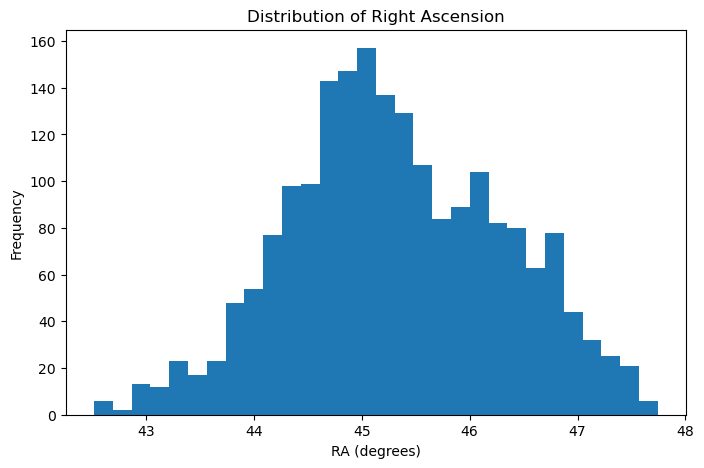

In [116]:
plt.figure(figsize=(8, 5))
plt.hist(gaia["ra"], bins=30)
plt.title("Distribution of Right Ascension")
plt.xlabel("RA (degrees)")
plt.ylabel("Frequency")
plt.show()

The right ascension distribution shows how stars are distributed across the sky. Unlike the synthetic dataset from Project 1, the distribution is not perfectly uniform, reflecting observational constraints and real spatial structure.

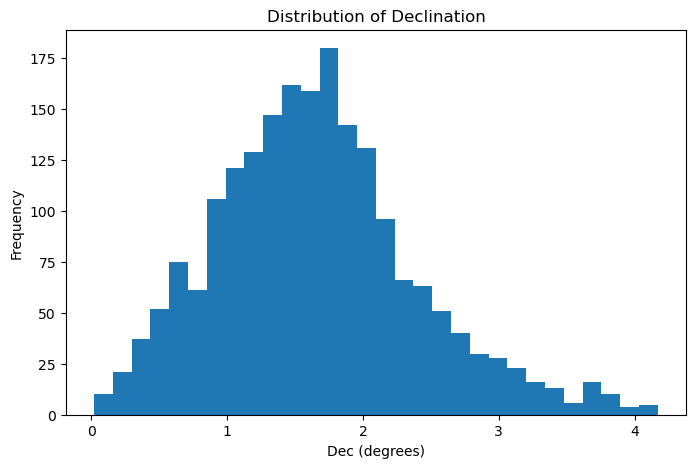

In [117]:
plt.figure(figsize=(8, 5))
plt.hist(gaia["dec"], bins=30)
plt.title("Distribution of Declination")
plt.xlabel("Dec (degrees)")
plt.ylabel("Frequency")
plt.show()

The declination distribution shows how stars are spread above and below the celestial equator. Any imbalance may reflect observational coverage rather than true symmetry.

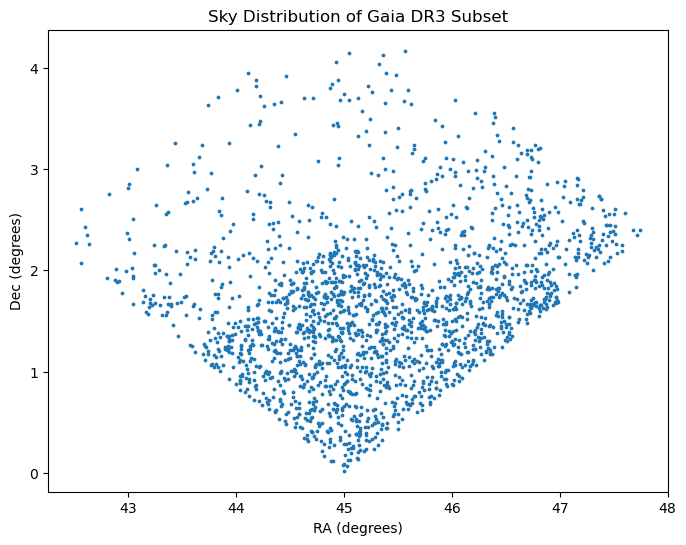

In [118]:
plt.figure(figsize=(8, 6))
plt.scatter(gaia["ra"], gaia["dec"], s=3)
plt.title("Sky Distribution of Gaia DR3 Subset")
plt.xlabel("RA (degrees)")
plt.ylabel("Dec (degrees)")
plt.show()

The scatter plot reveals the spatial structure of the dataset. Unlike the synthetic data, which was uniformly distributed, the Gaia data shows variations in density. These patterns suggest the presence of real astrophysical structure, such as star clusters or regions of higher stellar density.

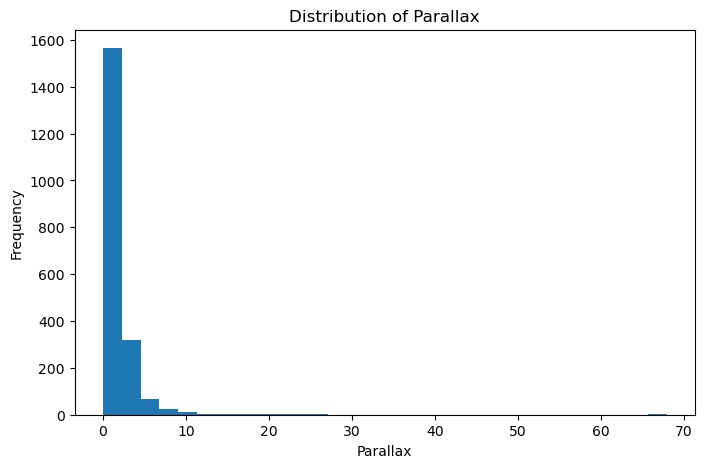

In [119]:
plt.figure(figsize=(8, 5))
plt.hist(gaia["parallax"], bins=30)
plt.title("Distribution of Parallax")
plt.xlabel("Parallax")
plt.ylabel("Frequency")
plt.show()

The parallax distribution indicates that most stars are relatively distant, with smaller parallax values being more common. This reflects the observational nature of the Gaia survey.

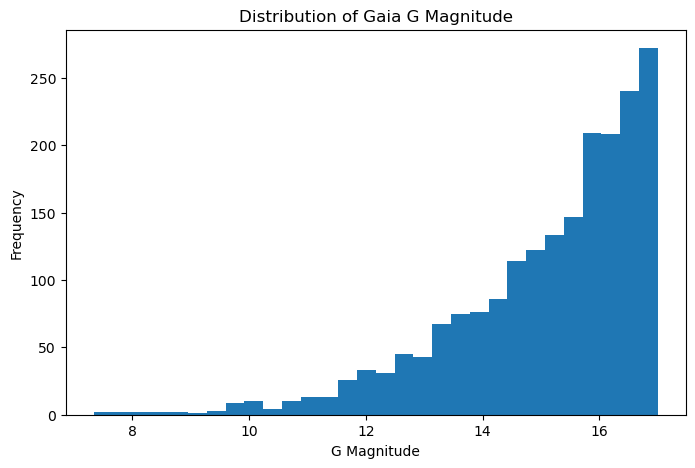

In [120]:
plt.figure(figsize=(8, 5))
plt.hist(gaia["phot_g_mean_mag"], bins=30)
plt.title("Distribution of Gaia G Magnitude")
plt.xlabel("G Magnitude")
plt.ylabel("Frequency")
plt.show()

The magnitude distribution shows that the dataset is biased toward brighter stars, due to the filtering applied in the data query. This is expected in observational astronomy.

# k-NN Graph Construction

A k-nearest neighbor graph connects each star to its k closest neighbors based on RA and Dec. This allows spatial relationships in the Gaia subset to be represented as a network.

In [121]:
coords = gaia[["ra", "dec"]].values

k = 5
nbrs = NearestNeighbors(n_neighbors=k + 1)
nbrs.fit(coords)

distances, indices = nbrs.kneighbors(coords)

G = nx.Graph()

for i in range(len(coords)):
    for j in indices[i][1:]:
        if i != j:
            G.add_edge(i, j)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())
print("Connected components:", nx.number_connected_components(G))
print("Average degree:", sum(dict(G.degree()).values()) / G.number_of_nodes())
print("Average clustering:", nx.average_clustering(G))

Nodes: 2000
Edges: 6041
Connected components: 1
Average degree: 6.041
Average clustering: 0.5451913059163059


In [122]:
k_values = [2, 5, 10, 15, 20]

metrics = []

for k in k_values:
    nbrs = NearestNeighbors(n_neighbors=k + 1)  # FIX
    nbrs.fit(coords)
    
    distances, indices = nbrs.kneighbors(coords)

    G_temp = nx.Graph()

    for i in range(len(coords)):
        for j in indices[i][1:]:  # skip self
            G_temp.add_edge(i, j)

    avg_degree = sum(dict(G_temp.degree()).values()) / G_temp.number_of_nodes()

    metrics.append({
        "k": k,
        "nodes": G_temp.number_of_nodes(),
        "edges": G_temp.number_of_edges(),
        "components": nx.number_connected_components(G_temp),
        "avg_degree": avg_degree,
        "clustering": nx.average_clustering(G_temp)
    })

metrics_df = pd.DataFrame(metrics)
metrics_df

,k,nodes,edges,components,avg_degree,clustering
0,2,2000,2590,101,2.590,0.449117
1,5,2000,6041,1,6.041,0.545191
2,10,2000,11608,1,11.608,0.572341
3,15,2000,17130,1,17.130,0.589451
4,20,2000,22688,1,22.688,0.598592


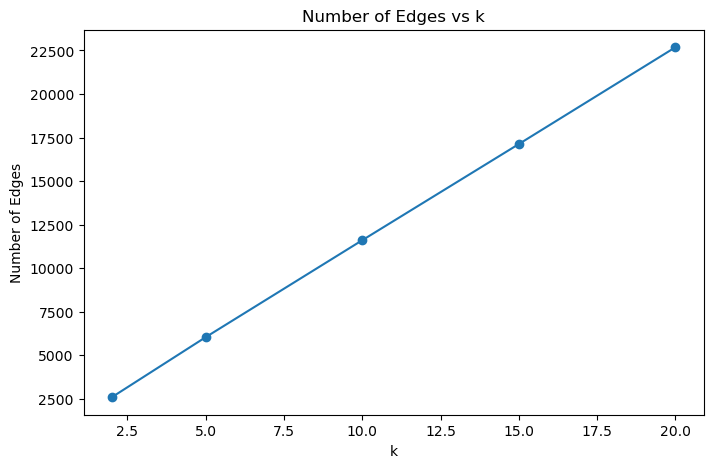

In [123]:
plt.figure(figsize=(8, 5))
plt.plot(metrics_df["k"], metrics_df["edges"], marker="o")
plt.title("Number of Edges vs k")
plt.xlabel("k")
plt.ylabel("Number of Edges")
plt.show()

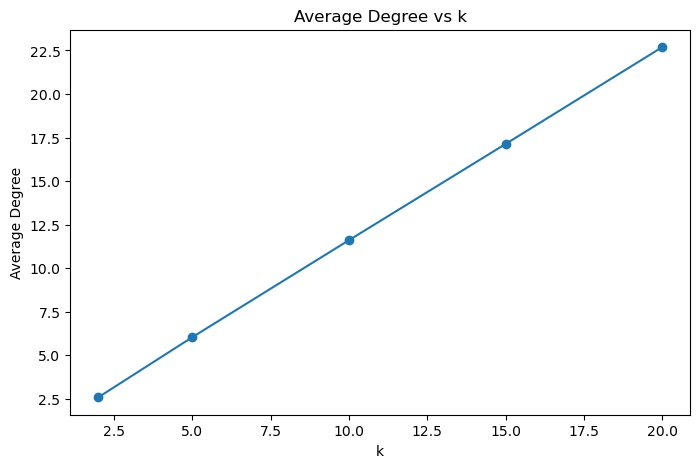

In [124]:
plt.figure(figsize=(8, 5))
plt.plot(metrics_df["k"], metrics_df["avg_degree"], marker="o")
plt.title("Average Degree vs k")
plt.xlabel("k")
plt.ylabel("Average Degree")
plt.show()

The number of edges increases approximately linearly with k. This is expected because each node is connected to its k nearest neighbors, leading to a proportional increase in total connections. As k grows, the graph becomes denser, reflecting stronger global connectivity across the dataset.

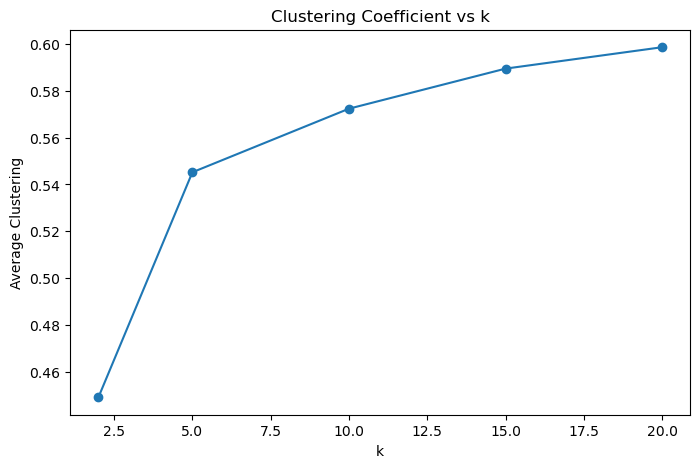

In [125]:
plt.figure(figsize=(8, 5))
plt.plot(metrics_df["k"], metrics_df["clustering"], marker="o")
plt.title("Clustering Coefficient vs k")
plt.xlabel("k")
plt.ylabel("Average Clustering")
plt.show()

The clustering coefficient increases rapidly at low values of k, indicating that local neighborhood structures form quickly as nodes begin connecting to nearby neighbors. At k = 2, clustering is near zero because there are not enough connections to form triangular relationships.

As k increases beyond 5, the clustering coefficient rises more slowly and begins to plateau. This suggests that most local structure is already established, and additional connections primarily increase graph density rather than introducing new clustering patterns.

Overall, this behavior reflects the emergence of meaningful local structure in the Gaia dataset, where stars exhibit spatial proximity relationships that lead to clustered neighborhoods.

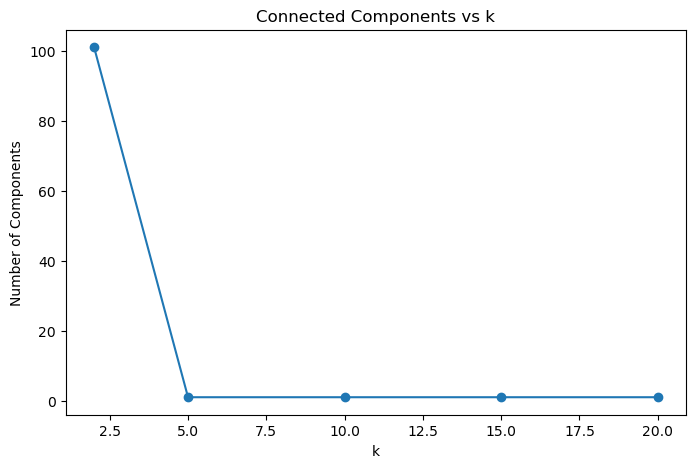

In [126]:
plt.figure(figsize=(8, 5))
plt.plot(metrics_df["k"], metrics_df["components"], marker="o")
plt.title("Connected Components vs k")
plt.xlabel("k")
plt.ylabel("Number of Components")
plt.show()

The number of connected components decreases dramatically as k increases. At k = 2, the graph consists of many disconnected components, indicating that most nodes are only locally connected or isolated.

However, by k = 5, the graph collapses into a single connected component, showing a rapid transition from a fragmented structure to a fully connected network. This demonstrates how even a small increase in neighborhood size can dramatically improve global connectivity.

This behavior highlights the emergence of large-scale structure in the Gaia dataset, where stars become part of a single connected system once enough local connections are established.

# Final Interpretation

The k-NN graph analysis reveals how local connectivity scales into global structure within the Gaia DR3 dataset. As k increases, the graph becomes denser, with the number of edges and average degree increasing approximately linearly. This reflects the direct relationship between neighborhood size and connectivity.

The clustering coefficient increases rapidly at low values of k, indicating that local neighborhoods quickly form tightly connected groups. However, this increase slows as k grows, suggesting that most local structure is established early.

Most notably, the number of connected components shows a sharp transition: the graph is highly fragmented at k = 2 but becomes fully connected by k = 5. This demonstrates a phase transition where local connections are sufficient to unify the entire network.

# Conclusion

This analysis shows that spatial relationships in real Gaia DR3 data produce meaningful graph structure when modeled using k-nearest neighbors. Compared to synthetic data, the real dataset exhibits stronger clustering and more rapid emergence of connectivity, reflecting underlying astrophysical structure.

Overall, the results highlight how graph-based methods can effectively capture both local and global spatial organization in astronomical data.